# Marketing Mix Modeling (MMM) Demo

This notebook fits a simple MMM using weekly data with columns:
`date, tv_spend, social_spend, search_spend, competitor_spend, sales`.

We apply adstock (carryover) and fit a linear regression, then plot and save charts.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

%matplotlib inline
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [2]:
def adstock(series: np.ndarray, decay: float = 0.5, max_lag: int = 4) -> np.ndarray:
    result = np.zeros_like(series, dtype=float)
    for i in range(len(series)):
        acc = series[i]
        for j in range(1, min(i, max_lag) + 1):
            acc += (decay ** j) * series[i - j]
        result[i] = acc
    return result

In [3]:
DATA_FILE = "sample_mmm_data.csv"

df = pd.read_csv(DATA_FILE, encoding="utf-8-sig")
df.rename(columns=lambda c: c.strip().lower(), inplace=True)

required = ["date","tv_spend","social_spend","search_spend","competitor_spend","sales"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"CSV missing: {missing}. Found: {list(df.columns)}")

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

display(df.head())
print(f"Rows: {len(df)} | Range: {df['date'].min().date()} → {df['date'].max().date()}")

,date,tv_spend,social_spend,search_spend,competitor_spend,sales
0,2023-01-01,"58,240.34","13,506.24","38,377.16","13,432.64","43,588.23"
1,2023-01-08,"43,743.09","16,329.34","31,666.28","23,767.95","57,393.70"
2,2023-01-15,"41,788.39","14,084.41","24,960.93","33,388.67","60,881.99"
3,2023-01-22,"41,789.26","25,609.62","25,067.27","50,368.64","53,499.34"
4,2023-01-29,"89,798.84","18,458.84","26,995.55","24,696.57","73,941.12"


Rows: 5 | Range: 2023-01-01 → 2023-01-29


In [4]:
DECAY = 0.5
MAX_LAG = 4

for col in ["tv_spend", "social_spend", "search_spend"]:
    df[f"{col}_adstock"] = adstock(df[col].values, decay=DECAY, max_lag=MAX_LAG)

feature_cols = ["tv_spend_adstock","social_spend_adstock","search_spend_adstock","competitor_spend"]
target_col = "sales"

X = df[feature_cols].copy()
y = df[target_col].copy()

display(X.head())

,tv_spend_adstock,social_spend_adstock,search_spend_adstock,competitor_spend
0,"58,240.34","13,506.24","38,377.16","13,432.64"
1,"72,863.26","23,082.46","50,854.86","23,767.95"
2,"78,220.02","25,625.64","50,388.36","33,388.67"
3,"80,899.27","38,422.44","50,261.45","50,368.64"
4,"130,248.48","37,670.06","52,126.28","24,696.57"


In [5]:
model = LinearRegression().fit(X, y)
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)

print(f"R-squared: {r2:.4f}")
print(f"Model intercept: {model.intercept_:,.2f}")

coefs = pd.Series(model.coef_, index=feature_cols, name="coefficient")
coefs.to_frame()

R-squared: 1.0000
Model intercept: -18,649.55


,coefficient
tv_spend_adstock,0.58
social_spend_adstock,-1.25
search_spend_adstock,1.04
competitor_spend,0.42


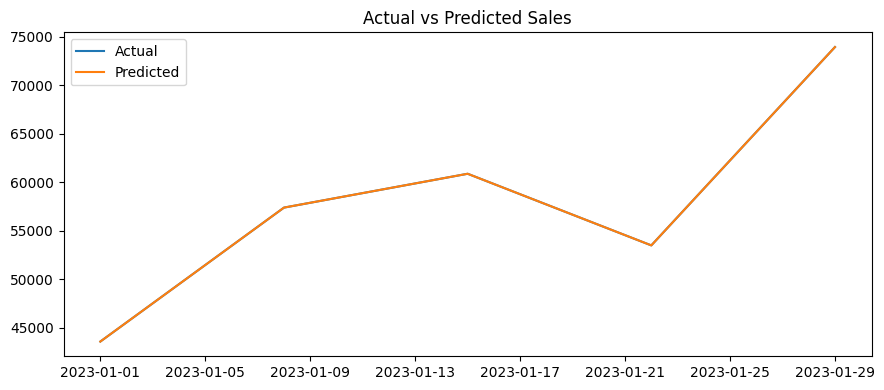

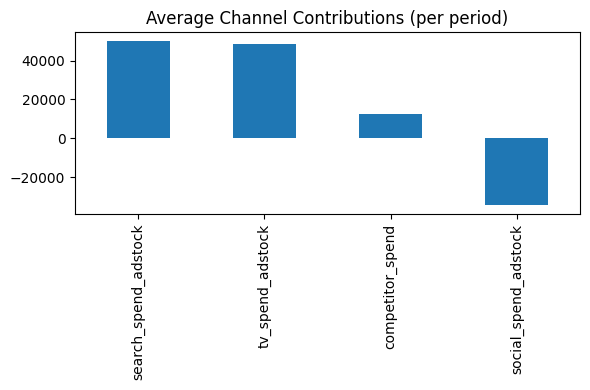

In [6]:
plt.figure(figsize=(9,4))
plt.plot(df["date"], y, label="Actual")
plt.plot(df["date"], y_pred, label="Predicted")
plt.title("Actual vs Predicted Sales")
plt.legend()
plt.tight_layout()
plt.show()

contrib = (X * model.coef_).mean().sort_values(ascending=False)
plt.figure(figsize=(6,4))
contrib.plot(kind="bar")
plt.title("Average Channel Contributions (per period)")
plt.tight_layout()
plt.show()

In [7]:
os.makedirs("output", exist_ok=True)

plt.figure(figsize=(9,4))
plt.plot(df["date"], y, label="Actual")
plt.plot(df["date"], y_pred, label="Predicted")
plt.title("Actual vs Predicted Sales")
plt.legend()
plt.tight_layout()
plt.savefig("output/actual_vs_predicted.png")
plt.close()

contrib = (X * model.coef_).mean().sort_values(ascending=False)
plt.figure(figsize=(6,4))
contrib.plot(kind="bar")
plt.title("Average Channel Contributions (per period)")
plt.tight_layout()
plt.savefig("output/channel_contributions.png")
plt.close()

print("Saved: output/actual_vs_predicted.png and output/channel_contributions.png")

Saved: output/actual_vs_predicted.png and output/channel_contributions.png
